<a href="https://colab.research.google.com/github/Rajya-5-sri/Exploratory-Data-Analysis-on-Online-Retail-Data/blob/main/Study_of_Impact_of_AI_on_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,MinMaxScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap #useful for understanding why a model made a certain decision.
import matplotlib.pyplot as plt
import joblib # In machine learning projects, it is commonly used to save trained models so you can reuse them later without retraining.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
import warnings
warnings.filterwarnings('ignore')


In [2]:

df = pd.read_csv("/content/drive/MyDrive/ai_student_impact_dataset (1).csv")

In [3]:
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [4]:
##DATA EXPLORATION:
df.head()


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.tail()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium
49999,150000,Arts,Sophomore,3.242,3.30,Copywriting/Drafting,Beginner,1,False,3.93,2,Allowed_With_Citation,6,3.261,76.16,Low


In [6]:
df.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


In [7]:
##check for duplicate and null values
missing_values = df.isnull().sum()
missing_values[missing_values>0]



,0


In [8]:
df.duplicated().sum()

np.int64(0)

***ANALYSING THE TARGET COLUMN***

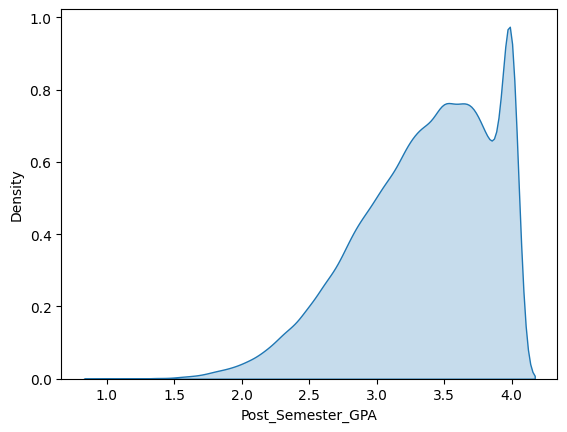

In [9]:
sns.kdeplot(df['Post_Semester_GPA'], fill=True)
plt.show()

<Axes: >

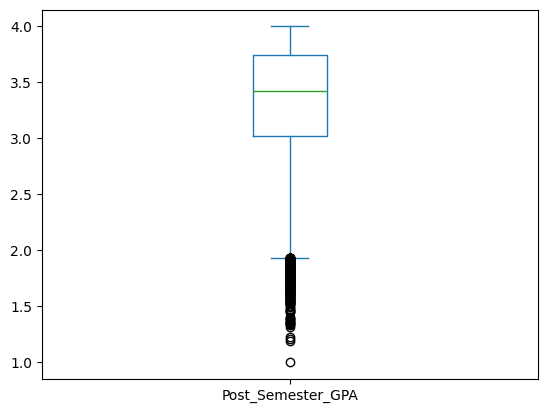

In [10]:
df['Post_Semester_GPA'].plot.box()



***the above KDE PLOT shows the GPA distribution is skewed left (most values near the top end, a long tail toward lower GPAs) and does not show clear, extreme outliers that must be removed automatically before linear regression***

***UNDERSTANDING THE CATEGORICAL COLUMNS***

In [11]:
for cols in df.columns:
    if df[cols].dtype == 'O':
        print(cols, df[cols].unique())

Major_Category ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']
Year_of_Study ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']
Primary_Use_Case ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']
Prompt_Engineering_Skill ['Beginner' 'Advanced' 'Intermediate']
Institutional_Policy ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']
Burnout_Risk_Level ['High' 'Low' 'Medium']


***DEPENDENCY SPLIT AND TRAIN-TEST-SPLIT***

In [12]:
target = "Post_Semester_GPA"

x = df.drop(columns=[target])
y = df[target]


# train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
x.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,100.00,Medium


In [14]:

y.head()

,Post_Semester_GPA
0,2.393
1,3.696
2,3.499
3,4.000
4,3.798


***ENCODING AND FIT-TRANSFORMING THE DATA***

In [15]:
# cat cols
cat_cols = [cols for cols in df.columns if df[cols].dtype == 'O']

# Encoding
encoder = OneHotEncoder(sparse_output=False, dtype='i', drop='first')

# training data
x_train_encoded = encoder.fit_transform(x_train[cat_cols])
x_train_encoded_df = pd.DataFrame(x_train_encoded, index=x_train.index, columns=encoder.get_feature_names_out())
x_train_encoded_df = pd.concat([x_train.drop(cat_cols, axis=1), x_train_encoded_df], axis=1)

# testing data
x_test_encoded = encoder.transform(x_test[cat_cols])
x_test_encoded_df = pd.DataFrame(x_test_encoded, index=x_test.index, columns=encoder.get_feature_names_out())
x_test_encoded_df = pd.concat([x_test.drop(cat_cols, axis=1), x_test_encoded_df], axis=1)

***DATA SCALING FOR INDEPENDENT AND TARGET VARIABLES***

In [16]:
# feature scaling
scaler = StandardScaler()

# train scaling
x_train_scaled = scaler.fit_transform(x_train_encoded_df)
x_train_scaled = pd.DataFrame(x_train_scaled,
                              index=x_train_encoded_df.index,
                              columns=scaler.get_feature_names_out())

# test scaling
x_test_scaled = scaler.transform(x_test_encoded_df)
x_test_scaled = pd.DataFrame(x_test_scaled,
                             index=x_test_encoded_df.index,
                             columns=scaler.get_feature_names_out())



***LINEAR REGRESSION MODEL BUILDING***

In [17]:
# train data sample
x_train_scaled.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Skill_Retention_Score,Major_Category_Business,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium
39087,0.972635,1.335546,0.501469,0.166223,-0.857267,-0.870319,-0.277330,-1.057744,0.433565,-0.577504,...,-0.568266,-0.381111,-0.522255,-0.458651,1.306768,-0.741719,0.989357,-0.492371,-0.697846,1.166199
30893,0.405224,1.266736,-0.881447,0.166223,-0.857267,0.043287,-0.277330,-1.057744,-2.239847,-0.577504,...,-0.568266,-0.381111,-0.522255,2.180307,1.306768,-0.741719,0.989357,-0.492371,1.432981,-0.857486
45278,1.401344,-0.447260,-0.580708,1.006690,-0.857267,0.242654,-1.375175,-1.057744,-0.387054,1.731589,...,-0.568266,-0.381111,1.914773,-0.458651,-0.765247,1.348219,-1.010758,-0.492371,-0.697846,1.166199
16398,-0.598514,1.460655,-0.282385,-0.674243,-0.857267,1.589836,0.271593,0.804584,-0.125811,-0.577504,...,-0.568266,2.623906,-0.522255,-0.458651,1.306768,-0.741719,0.989357,-0.492371,1.432981,-0.857486
13653,-0.788598,-2.394794,0.692299,1.847157,-0.857267,0.337499,1.369439,0.339002,-0.186040,1.731589,...,-0.568266,-0.381111,1.914773,-0.458651,-0.765247,1.348219,-1.010758,-0.492371,-0.697846,1.166199


**In standardization, the data is centered around 0, not forced into the 0 to 1 range.**

**So values less than the mean become negative, and values greater than the mean become positive.**



***MULTIPLE LINEAR REGRESSION***

In [18]:
# add constant
lr_data = sm.add_constant(x_train_scaled[['Pre_Semester_GPA','Weekly_GenAI_Hours','Prompt_Engineering_Skill_Beginner','Traditional_Study_Hours','Prompt_Engineering_Skill_Intermediate']])

# fit the data onto the ols model
lr_model = sm.OLS(y_train, lr_data).fit()

# model parameters
print(round(lr_model.params,4))

const                                    3.3481
Pre_Semester_GPA                         0.4612
Weekly_GenAI_Hours                       0.0019
Prompt_Engineering_Skill_Beginner       -0.0297
Traditional_Study_Hours                  0.0711
Prompt_Engineering_Skill_Intermediate   -0.0291
dtype: float64


 **For OLS in statsmodels you do not need (or usually want) to scale y_train, only the features X**
 **const = 3.3481 means the predicted Post_Semester_GPA when all predictors are 0, which is mostly a baseline term and not always meaningful in practice.**

**Pre_Semester_GPA = 0.4612 means students with higher starting GPA tend to end with higher GPA too.**

**Weekly_GenAI_Hours = 0.0019 is very small, so AI usage has only a tiny positive association here.**

**Traditional_Study_Hours = 0.0711 suggests more traditional studying is associated with better end GPA.**

**Prompt_Engineering_Skill_Beginner = -0.0297 and Prompt_Engineering_Skill_Intermediate = -0.0291 mean these groups are slightly lower than the reference prompt-skill group.**




In [19]:
# model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                 5.988e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:17:07   Log-Likelihood:                 13999.
No. Observations:               40000   AIC:                        -2.799e+04
Df Residuals:                   39994   BIC:                        -2.793e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

***All predictors except the intercept are statistically significant at the 5% level, since their p-values are below 0.05. The very large t-values for Pre_Semester_GPA and Traditional_Study_Hours show they are especially strong contributors***



In [20]:
# ALL AT ONCE

# add constant
mlr_data = sm.add_constant(x_train_scaled)

# fit the data onto the ols model
mlr_model = sm.OLS(y_train, mlr_data).fit()

# model summary
print(mlr_model.summary())


                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                 1.279e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:17:09   Log-Likelihood:                 16550.
No. Observations:               40000   AIC:                        -3.304e+04
Df Residuals:                   39972   BIC:                        -3.280e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

**Pre_Semester_GPA has by far the largest t-value, so starting academic performance is the strongest predictor.**

**Traditional_Study_Hours is also very strong and positive, which means more non-AI study time is linked with better GPA.**

**Weekly_GenAI_Hours is positive and significant, but the effect size is small.**

**Paid_Subscription is also positive and significant, but again the effect is small.**

**Prompt_Engineering_Skill_Beginner and Prompt_Engineering_Skill_Intermediate are both negative, meaning they perform worse than the reference prompt-skill group.**

***some variables are statistically insignificat (not useful for the analysis / not contributing)***
    *** # reason can be that it may have multicollinearlity (high correlation/ covariance between the independent variable)
    # using VIF (variace inflation factor) we can fix the insignificance
    # VIF method - VIF > 5 is bad (high multicolinearity)***

In [21]:
# Remove leakage columns from features
x_train_clean = x_train_scaled.drop(
    ['Skill_Retention_Score', 'Burnout_Risk_Level_Low', 'Burnout_Risk_Level_Medium'],
    axis=1,
    errors='ignore'
)

# Add constant
mlr_data = sm.add_constant(x_train_clean)

# Fit OLS model
mlr_model = sm.OLS(y_train, mlr_data).fit()

# Model summary
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 1.426e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:17:10   Log-Likelihood:                 16385.
No. Observations:               40000   AIC:                        -3.272e+04
Df Residuals:                   39975   BIC:                        -3.250e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

**Skill_Retention_Score and Burnout_Risk_Level should not usually be used as predictors for Post_Semester_GPA if our goal is to predict GPA realistically. They are outcomes or closely related post-semester variables, so including them can cause data leakage and make the model look better than it would in a real prediction setting.**

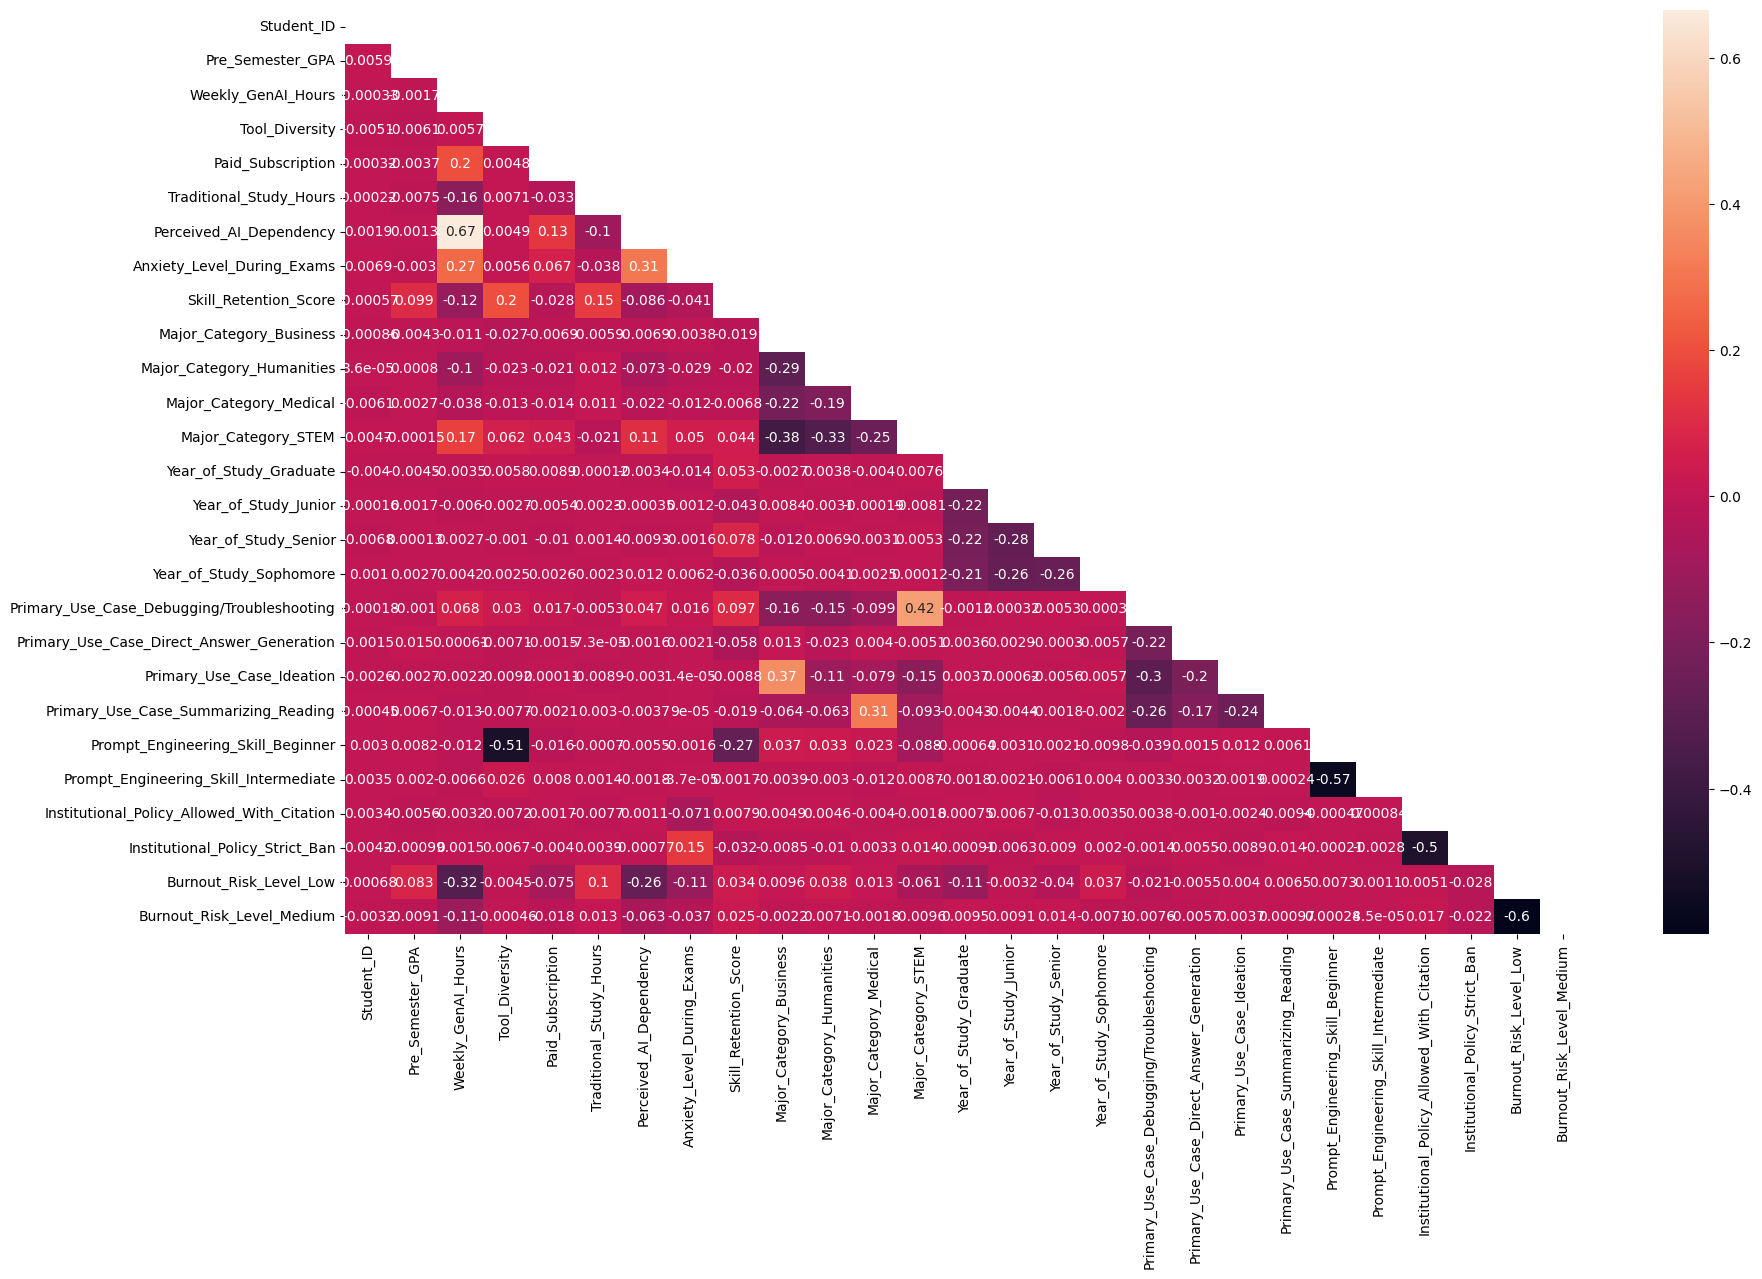

In [22]:
# heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(x_train_scaled.corr(), annot=True, mask=np.triu(x_train_scaled.corr()))
plt.show()

***Correlation near 0.0 means not redundant.***

***Correlation around 0.3–0.6 means moderate relationship.***

***Correlation above 0.8 usually means one of the pair may be redundant.***

***A correlation heatmap helps you quickly see which features move together, which are redundant, and which might be good candidates for your regression model.
Each cell shows the correlation between two variables, using color to encode the correlation value (usually from -1 to 1).
Warm colors (reds/oranges) typically mean strong positive correlation; cool colors (blues) mean strong negative correlation; near-zero correlations are often light/neutral colors.***
***From the above graph, it is evident that the data doesnot contain any redundants***

In [23]:
# droping the 'Student_ID','Tool_Diversity','Major_Category_Business','Major_Category_Humanities','Major_Category_Medical','Major_Category_STEM','Primary_Use_Case_Ideation','Primary_Use_Case_Summarizing_Reading' as the value of p>0.05
x_train_clean2 = x_train_clean.drop(['Student_ID','Tool_Diversity','Major_Category_Business','Major_Category_Humanities','Major_Category_Medical','Major_Category_STEM','Primary_Use_Case_Ideation','Primary_Use_Case_Summarizing_Reading'], axis=1)

In [24]:
# refitting the data
# add constant
mlr_data_2 = sm.add_constant(x_train_clean2)

# fit the data onto the ols model
mlr_model_2 = sm.OLS(y_train, mlr_data_2).fit()

# model summary
print(mlr_model_2.summary())

                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 2.139e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:17:15   Log-Likelihood:                 16380.
No. Observations:               40000   AIC:                        -3.273e+04
Df Residuals:                   39983   BIC:                        -3.258e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [25]:
# dataframe with column name and respective vif

vif_df = pd.DataFrame()
vif_df['Feature'] = x_train_clean2.columns
vif_df['VIF'] = [round(vif(x_train_clean2.values, i), 2) for i in range(x_train_clean2.shape[1])]
vif_df.sort_values(by='VIF', ascending=False, inplace=True)
vif_df


,Feature,VIF
1,Weekly_GenAI_Hours,1.88
4,Perceived_AI_Dependency,1.86
7,Year_of_Study_Junior,1.56
8,Year_of_Study_Senior,1.55
9,Year_of_Study_Sophomore,1.52
13,Prompt_Engineering_Skill_Intermediate,1.48
12,Prompt_Engineering_Skill_Beginner,1.48
6,Year_of_Study_Graduate,1.42
15,Institutional_Policy_Strict_Ban,1.35
14,Institutional_Policy_Allowed_With_Citation,1.33


In [26]:
# Final selected features
x_train_final = x_train_clean2

# Add intercept
mlr_data = sm.add_constant(x_train_final)

# Fit OLS model
mlr_model = sm.OLS(y_train, mlr_data).fit()

# Summary
print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 2.139e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:17:24   Log-Likelihood:                 16380.
No. Observations:               40000   AIC:                        -3.273e+04
Df Residuals:                   39983   BIC:                        -3.258e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [27]:
#  Preparing train/test matrices
x_test_final = x_test_scaled[x_train_final.columns]

x_train_final = sm.add_constant(x_train_final)
x_test_final = sm.add_constant(x_test_final, has_constant='add')


In [29]:
#  Fit OLS model

mlr_model = sm.OLS(y_train, x_train_final).fit()
print(mlr_model.summary())


                            OLS Regression Results                            
Dep. Variable:      Post_Semester_GPA   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 2.139e+04
Date:                Sun, 26 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:20:21   Log-Likelihood:                 16380.
No. Observations:               40000   AIC:                        -3.273e+04
Df Residuals:                   39983   BIC:                        -3.258e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [30]:
#  Predictions

y_train_pred = mlr_model.predict(x_train_final)
y_test_pred = mlr_model.predict(x_test_final)

In [31]:
#  Train/test evaluation

def regression_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Metrics")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")
    print("-" * 30)

regression_metrics(y_train, y_train_pred, "Train")
regression_metrics(y_test, y_test_pred, "Test")




Train Metrics
MAE : 0.1260
RMSE: 0.1607
R2  : 0.8954
------------------------------
Test Metrics
MAE : 0.1242
RMSE: 0.1583
R2  : 0.8962
------------------------------


**MAE (Mean Absolute Error) = average absolute prediction error.**

**RMSE (Root Mean Squared Error) = similar to MAE, but penalizes larger mistakes more.**

**R2 = how much of the variation in Post_Semester_GPA your model explains.**


***The model is not overfitting much, because the train and test scores are nearly identical. That means the regression is stable and the selected features are giving a consistent pattern.***

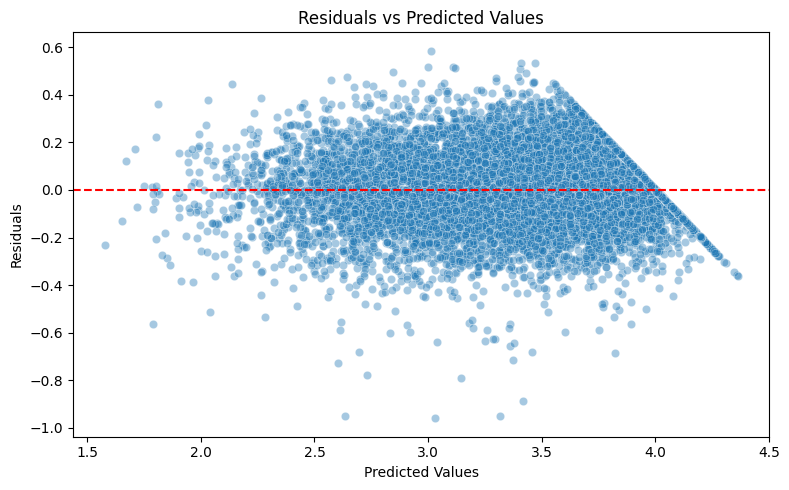

In [32]:
# Residual plot

residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

**The above graph is called a residual plot or more specifically a residuals vs fitted values plot.**
**In this graph:**

**the x-axis is the predicted values,**

**the y-axis is the residuals = actual value minus predicted value,**

**the red line at 0 shows where the prediction error is zero**

***In the residual plot, points should be scattered randomly around 0 with no clear curve or funnel shape. That usually means the linear model is behaving reasonably well***

***The model is doing a good job, but it is less stable at some GPA ranges, especially near the upper end. That is common when predicting a score with a fixed ceiling like GPA***

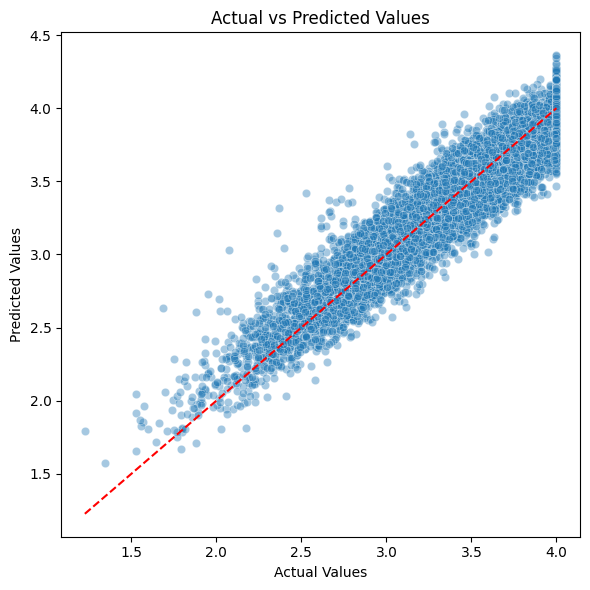

In [33]:
#  Actual vs predicted plot

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.tight_layout()
plt.show()

***In the actual vs predicted plot, points closer to the diagonal line mean better predictions***

In [34]:
# Short interpretation of significant variables

sig_vars = mlr_model.pvalues[mlr_model.pvalues < 0.05].sort_values()
print("\nSignificant variables (p < 0.05):")
print(sig_vars)

print("\nShort interpretation:")
print("- Pre_Semester_GPA is the strongest positive predictor of Post_Semester_GPA.")
print("- Traditional_Study_Hours also has a strong positive effect.")
print("- Weekly_GenAI_Hours has a small positive association with GPA.")
print("- Higher Perceived_AI_Dependency and Anxiety_Level_During_Exams are linked with slightly lower GPA.")
print("- Beginner and Intermediate prompt engineering skills are associated with lower GPA compared with the reference group.")
print("- Strict AI ban policy is linked with lower GPA, while Allowed_With_Citation is slightly positive.")


Significant variables (p < 0.05):
const                                          0.000000e+00
Pre_Semester_GPA                               0.000000e+00
Year_of_Study_Graduate                         0.000000e+00
Traditional_Study_Hours                        0.000000e+00
Year_of_Study_Senior                           0.000000e+00
Year_of_Study_Junior                           0.000000e+00
Prompt_Engineering_Skill_Beginner             1.510188e-183
Prompt_Engineering_Skill_Intermediate         1.867132e-183
Primary_Use_Case_Direct_Answer_Generation     1.108319e-156
Primary_Use_Case_Debugging/Troubleshooting    1.564470e-135
Year_of_Study_Sophomore                        1.445601e-76
Institutional_Policy_Strict_Ban                3.842048e-12
Paid_Subscription                              1.178103e-11
Anxiety_Level_During_Exams                     1.133944e-05
Perceived_AI_Dependency                        1.175070e-02
Institutional_Policy_Allowed_With_Citation     2.385653e-02
Weekl